# Prediccion del consumo de energia electrica con red neuronal

Este proyecto analiza el comportamiento de consumo electrico dentro del sistema regional **PJM Interconnection** en Estados Unidos. No se estudia una sola ciudad, sino un sistema electrico regional compuesto por varias zonas de consumo.

PJM Interconnection es una organizacion regional de transmision electrica de Estados Unidos. Opera en varios estados del este y medio oeste del pais, incluyendo Pennsylvania, New Jersey, Maryland, Ohio, Virginia, Illinois, Delaware y el Distrito de Columbia.

Se usara el archivo `dataset/pjm_hourly_est.csv`, que contiene registros historicos por hora de varias regiones o zonas de consumo dentro del sistema PJM. El objetivo es entrenar una red neuronal para predecir la carga total estimada del sistema PJM en megavatios (MW).

Este es un problema de **regresion supervisada**, porque el modelo aprende con ejemplos historicos donde existe un valor numerico objetivo y luego predice un consumo continuo.


## Variables de entrada

El modelo recibe consumos de distintas zonas del sistema PJM, junto con variables de tiempo y consumo historico. Estas variables permiten representar tanto el comportamiento regional como los patrones horarios, semanales y estacionales.

Las variables de entrada que se usaran son:

- `AEP`
- `COMED`
- `DAYTON`
- `DEOK`
- `DOM`
- `DUQ`
- `EKPC`
- `FE`
- `NI`
- `PJME`
- `PJMW`
- `hora`
- `dia_semana`
- `mes`
- `anio`
- `consumo_hace_1_hora`
- `consumo_hace_24_horas`
- `consumo_hace_7_dias`
- `promedio_24_horas`


## Variable a predecir

La variable a predecir es `PJM_Load`.

Esta columna representa la **carga total estimada del sistema PJM en MW**. El objetivo del modelo es estimar ese valor usando el comportamiento regional, las variables de tiempo y el consumo historico.


## 1. Importar librerias

Primero se importan las librerias necesarias para cargar datos, procesarlos, visualizarlos, crear la red neuronal y evaluar sus resultados.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('ggplot')


## 2. Entendiendo el dataset

El archivo `pjm_hourly_est.csv` contiene varias regiones o zonas de consumo dentro del sistema PJM. Cada fila representa una medicion o estimacion asociada a una fecha y hora.

A continuacion se carga el dataset y se revisan sus primeras filas, columnas y dimensiones generales.


In [2]:
ruta_dataset = Path("dataset/pjm_hourly_est.csv")
df = pd.read_csv(ruta_dataset)
columna_objetivo = "PJM_Load"

columnas_regionales = [
    'AEP',
    'COMED',
    'DAYTON',
    'DEOK',
    'DOM',
    'DUQ',
    'EKPC',
    'FE',
    'NI',
    'PJME',
    'PJMW'
]

print(f'Archivo usado: {ruta_dataset}')
print(f'Columna objetivo: {columna_objetivo}')
display(df.head())


Archivo usado: dataset\pjm_hourly_est.csv
Columna objetivo: PJM_Load


,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [3]:
resumen_dataset = pd.DataFrame({
    'Descripcion': ['Filas', 'Columnas'],
    'Cantidad': [df.shape[0], df.shape[1]]
})

columnas_dataset = pd.DataFrame({'Columnas del dataset': df.columns})

display(resumen_dataset)
display(columnas_dataset)


,Descripcion,Cantidad
0,Filas,178262
1,Columnas,13


,Columnas del dataset
0,Datetime
1,AEP
2,COMED
3,DAYTON
4,DEOK
5,DOM
6,DUQ
7,EKPC
8,FE
9,NI


## 3. Columnas del dataset

La siguiente tabla describe las columnas principales del archivo. Las zonas representan diferentes areas de consumo dentro del sistema PJM.


In [4]:
descripcion_dataset = pd.DataFrame({
    'Columna': [
        'Datetime',
        'AEP',
        'COMED',
        'DAYTON',
        'DEOK',
        'DOM',
        'DUQ',
        'EKPC',
        'FE',
        'NI',
        'PJME',
        'PJMW',
        'PJM_Load'
    ],
    'Descripcion': [
        'Fecha y hora del registro.',
        'Consumo de la zona AEP.',
        'Consumo de la zona COMED.',
        'Consumo de la zona DAYTON.',
        'Consumo de la zona DEOK.',
        'Consumo de la zona DOM.',
        'Consumo de la zona DUQ.',
        'Consumo de la zona EKPC.',
        'Consumo de la zona FE.',
        'Consumo de la zona NI.',
        'Consumo de la zona PJM East.',
        'Consumo de la zona PJM West.',
        'Carga total estimada del sistema PJM.'
    ]
})

display(descripcion_dataset)


,Columna,Descripcion
0,Datetime,Fecha y hora del registro.
1,AEP,Consumo de la zona AEP.
2,COMED,Consumo de la zona COMED.
3,DAYTON,Consumo de la zona DAYTON.
4,DEOK,Consumo de la zona DEOK.
5,DOM,Consumo de la zona DOM.
6,DUQ,Consumo de la zona DUQ.
7,EKPC,Consumo de la zona EKPC.
8,FE,Consumo de la zona FE.
9,NI,Consumo de la zona NI.


## 4. Limpieza y preparacion de datos

Para trabajar con una serie temporal se convierte la columna `Datetime` a formato de fecha, se ordenan los registros y se convierten las columnas numericas.

El archivo integrado tiene zonas con diferentes periodos de disponibilidad. Por eso se identifican los registros que tienen informacion regional, se completan como cero las zonas sin registro en una hora determinada y se eliminan los valores nulos restantes antes de entrenar.

Cuando `PJM_Load` no esta disponible pero existen consumos regionales en la fila, se completa como la suma de las zonas disponibles para construir una carga total estimada del sistema PJM.


In [5]:
datos = df.copy()

if 'Datetime' not in datos.columns:
    raise ValueError('El dataset debe contener una columna llamada Datetime.')

columnas_requeridas = columnas_regionales + [columna_objetivo]
columnas_faltantes = [col for col in columnas_requeridas if col not in datos.columns]

if columnas_faltantes:
    raise ValueError(f'Faltan columnas requeridas: {columnas_faltantes}')

# Se convierten las fechas y columnas numericas.
datos['Datetime'] = pd.to_datetime(datos['Datetime'], errors='coerce')
columnas_numericas = [col for col in datos.columns if col != 'Datetime']
datos[columnas_numericas] = datos[columnas_numericas].apply(pd.to_numeric, errors='coerce')

resumen_nulos = pd.DataFrame({
    'Columna': datos.columns,
    'Valores nulos': datos.isna().sum().values
})

display(resumen_nulos)


,Columna,Valores nulos
0,Datetime,0
1,AEP,56989
2,COMED,111765
3,DAYTON,56987
4,DEOK,120523
5,DOM,62073
6,DUQ,59194
7,EKPC,132928
8,FE,115388
9,NI,119812


In [6]:
# Se conservan filas con informacion regional disponible.
tiene_region = datos[columnas_regionales].notna().any(axis=1)

datos[columnas_regionales] = datos[columnas_regionales].fillna(0)
datos.loc[datos[columna_objetivo].isna(), columna_objetivo] = datos.loc[
    datos[columna_objetivo].isna(), columnas_regionales
].sum(axis=1)

datos = datos[tiene_region].copy()
datos = datos.dropna(subset=['Datetime'] + columnas_regionales + [columna_objetivo])
datos = datos.sort_values('Datetime').drop_duplicates(subset='Datetime')
datos = datos.reset_index(drop=True)

resumen_limpieza = pd.DataFrame({
    'Descripcion': [
        'Filas originales',
        'Filas con informacion regional',
        'Filas despues de eliminar nulos'
    ],
    'Cantidad': [len(df), int(tiene_region.sum()), len(datos)]
})

display(resumen_limpieza)
display(datos.head())


,Descripcion,Cantidad
0,Filas originales,178262
1,Filas con informacion regional,145366
2,Filas despues de eliminar nulos,145362


,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,2002-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30393.0,0.0,30393.0
1,2002-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29265.0,0.0,29265.0
2,2002-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28357.0,0.0,28357.0
3,2002-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27899.0,0.0,27899.0
4,2002-01-01 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28057.0,0.0,28057.0


## 5. Creacion de variables de entrada

A partir de la fecha se crean variables temporales. A partir de `PJM_Load` se crean variables de consumo historico mediante desplazamientos.

Estas variables ayudan a la red neuronal a reconocer ciclos diarios, semanales y tendencias recientes del sistema PJM.


In [7]:
datos['hora'] = datos['Datetime'].dt.hour
datos['dia_semana'] = datos['Datetime'].dt.dayofweek
datos['mes'] = datos['Datetime'].dt.month
datos['anio'] = datos['Datetime'].dt.year

datos['consumo_hace_1_hora'] = datos[columna_objetivo].shift(1)
datos['consumo_hace_24_horas'] = datos[columna_objetivo].shift(24)
datos['consumo_hace_7_dias'] = datos[columna_objetivo].shift(24 * 7)
datos['promedio_24_horas'] = datos[columna_objetivo].shift(1).rolling(window=24).mean()

variables_temporales = ['hora', 'dia_semana', 'mes', 'anio']
variables_historicas = [
    'consumo_hace_1_hora',
    'consumo_hace_24_horas',
    'consumo_hace_7_dias',
    'promedio_24_horas'
]

variables_entrada = columnas_regionales + variables_temporales + variables_historicas

datos_modelo = datos.dropna(subset=variables_entrada + [columna_objetivo]).reset_index(drop=True)

print(f'Filas despues de crear variables historicas: {len(datos_modelo)}')
display(datos_modelo[['Datetime', columna_objetivo] + variables_entrada].head())


Filas despues de crear variables historicas: 145194


,Datetime,PJM_Load,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,...,PJME,PJMW,hora,dia_semana,mes,anio,consumo_hace_1_hora,consumo_hace_24_horas,consumo_hace_7_dias,promedio_24_horas
0,2002-01-08 01:00:00,29445.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29445.0,0.0,1,1,1,2002,31187.0,26862.0,30393.0,33452.583333
1,2002-01-08 02:00:00,28670.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28670.0,0.0,2,1,1,2002,29445.0,25976.0,29265.0,33560.208333
2,2002-01-08 03:00:00,28375.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28375.0,0.0,3,1,1,2002,28670.0,25641.0,28357.0,33672.458333
3,2002-01-08 04:00:00,28542.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28542.0,0.0,4,1,1,2002,28375.0,25666.0,27899.0,33786.375000
4,2002-01-08 05:00:00,29261.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29261.0,0.0,5,1,1,2002,28542.0,26328.0,28057.0,33906.208333


## 6. Explicacion de las variables del modelo

La siguiente tabla resume que representa cada variable de entrada y por que puede ayudar a la red neuronal.


In [8]:
explicacion_regiones = pd.DataFrame({
    'Columna': columnas_regionales,
    'Que representa': [f'Consumo de la zona {zona}.' for zona in columnas_regionales],
    'Por que ayuda al modelo': [
        'Aporta informacion regional directa para estimar la carga total del sistema PJM.'
    ] * len(columnas_regionales)
})

explicacion_tiempo = pd.DataFrame({
    'Columna': variables_temporales + variables_historicas,
    'Que representa': [
        'Hora del dia de la medicion.',
        'Dia de la semana, donde 0 es lunes y 6 es domingo.',
        'Mes de la medicion.',
        'Anio de la medicion.',
        'Carga total estimada una hora antes.',
        'Carga total estimada 24 horas antes.',
        'Carga total estimada 7 dias antes.',
        'Promedio de carga de las 24 horas anteriores.'
    ],
    'Por que ayuda al modelo': [
        'Captura rutinas diarias de consumo electrico.',
        'Permite distinguir patrones entre dias laborales y fines de semana.',
        'Ayuda a reconocer cambios estacionales.',
        'Representa tendencias de largo plazo.',
        'Aporta informacion inmediata del comportamiento reciente.',
        'Compara el consumo con la misma hora del dia anterior.',
        'Compara el consumo con el mismo momento de la semana anterior.',
        'Resume la demanda reciente y suaviza variaciones puntuales.'
    ]
})

explicacion_variables = pd.concat([explicacion_regiones, explicacion_tiempo], ignore_index=True)
display(explicacion_variables)


,Columna,Que representa,Por que ayuda al modelo
0,AEP,Consumo de la zona AEP.,Aporta informacion regional directa para estim...
1,COMED,Consumo de la zona COMED.,Aporta informacion regional directa para estim...
2,DAYTON,Consumo de la zona DAYTON.,Aporta informacion regional directa para estim...
3,DEOK,Consumo de la zona DEOK.,Aporta informacion regional directa para estim...
4,DOM,Consumo de la zona DOM.,Aporta informacion regional directa para estim...
5,DUQ,Consumo de la zona DUQ.,Aporta informacion regional directa para estim...
6,EKPC,Consumo de la zona EKPC.,Aporta informacion regional directa para estim...
7,FE,Consumo de la zona FE.,Aporta informacion regional directa para estim...
8,NI,Consumo de la zona NI.,Aporta informacion regional directa para estim...
9,PJME,Consumo de la zona PJME.,Aporta informacion regional directa para estim...


## 7. Visualizacion de datos

Las graficas permiten observar patrones importantes antes de entrenar el modelo. Se revisa la carga total estimada y sus promedios por hora, dia de la semana y mes.


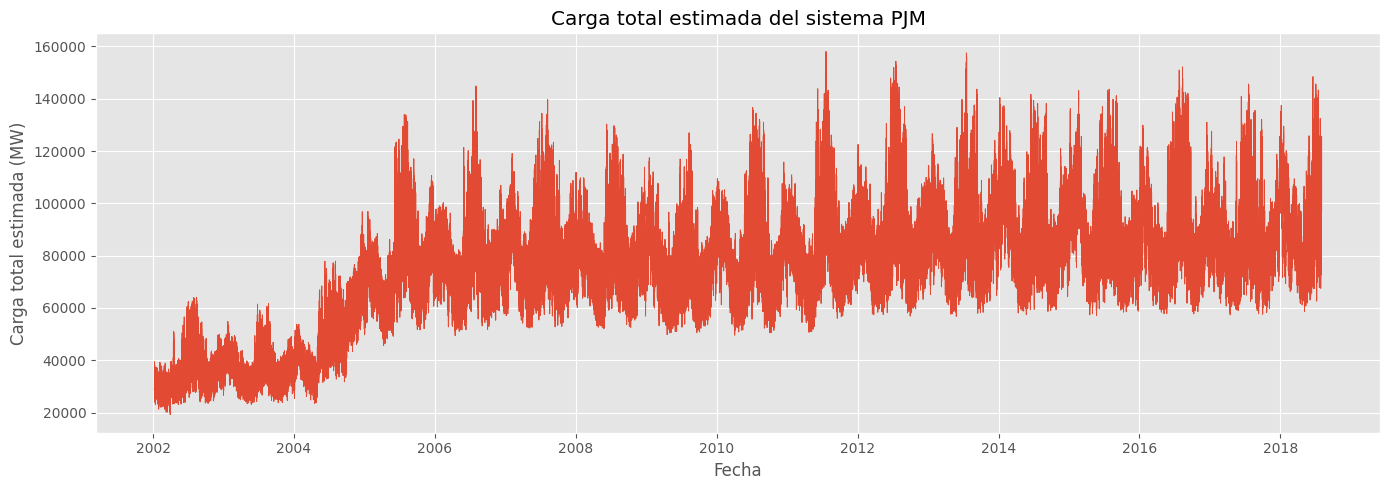

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(datos_modelo['Datetime'], datos_modelo[columna_objetivo], linewidth=0.7)
plt.title('Carga total estimada del sistema PJM')
plt.xlabel('Fecha')
plt.ylabel('Carga total estimada (MW)')
plt.tight_layout()
plt.show()


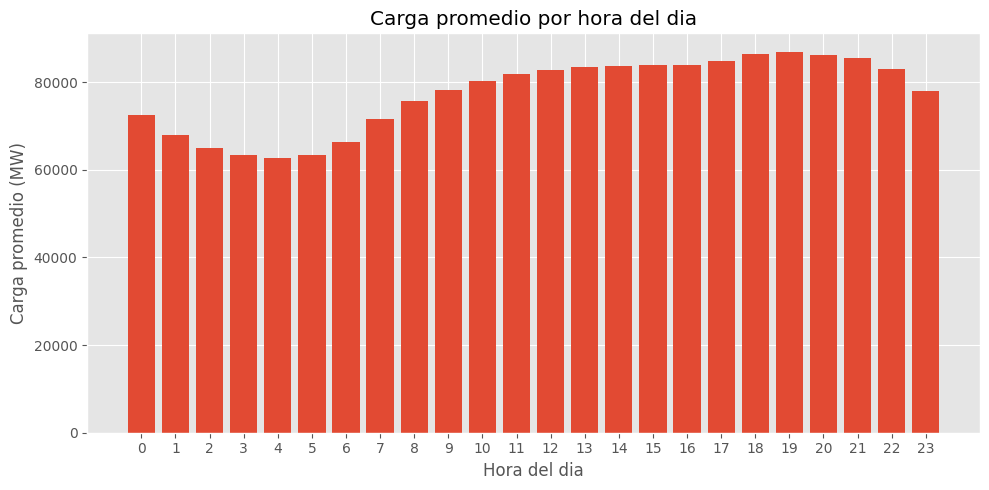

In [10]:
promedio_por_hora = datos_modelo.groupby('hora')[columna_objetivo].mean()

plt.figure(figsize=(10, 5))
plt.bar(promedio_por_hora.index, promedio_por_hora.values)
plt.title('Carga promedio por hora del dia')
plt.xlabel('Hora del dia')
plt.ylabel('Carga promedio (MW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


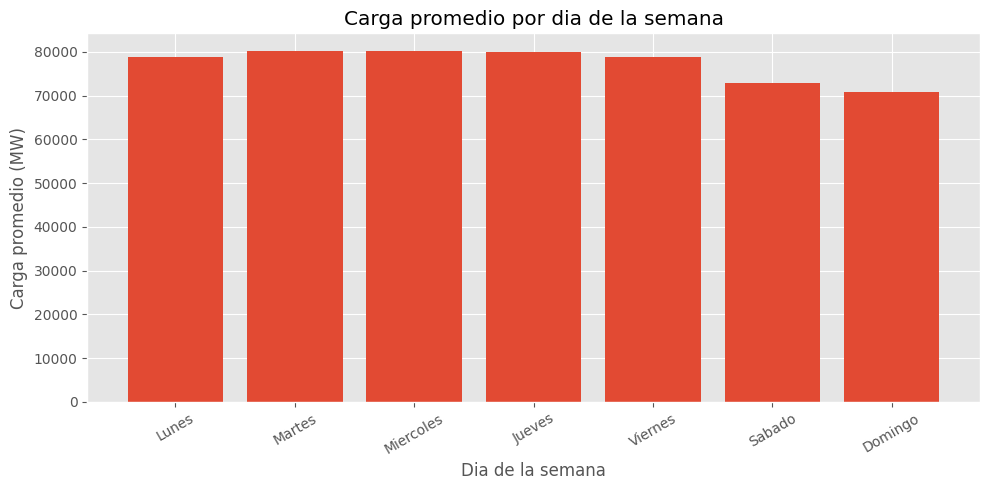

In [11]:
nombres_dias = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miercoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sabado',
    6: 'Domingo'
}

promedio_por_dia = datos_modelo.groupby('dia_semana')[columna_objetivo].mean()
etiquetas_dias = [nombres_dias[dia] for dia in promedio_por_dia.index]

plt.figure(figsize=(10, 5))
plt.bar(etiquetas_dias, promedio_por_dia.values)
plt.title('Carga promedio por dia de la semana')
plt.xlabel('Dia de la semana')
plt.ylabel('Carga promedio (MW)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


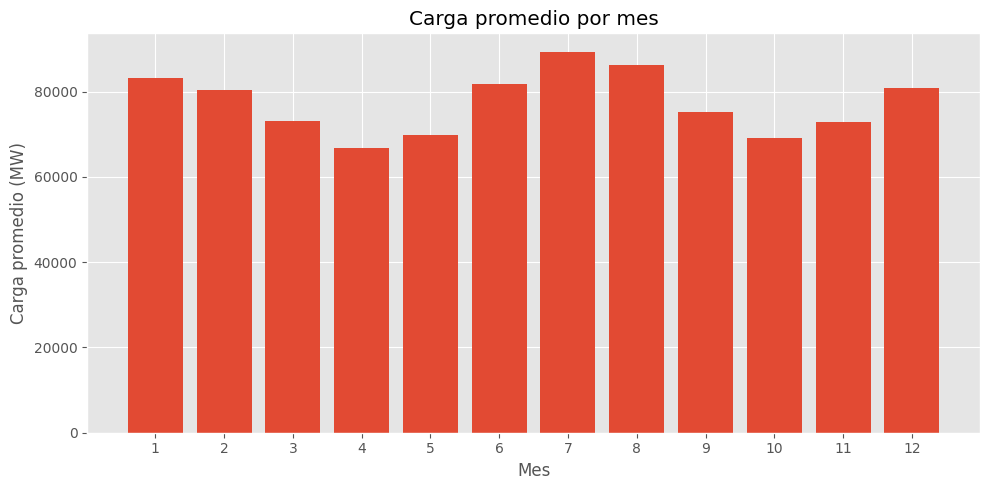

In [12]:
promedio_por_mes = datos_modelo.groupby('mes')[columna_objetivo].mean()

plt.figure(figsize=(10, 5))
plt.bar(promedio_por_mes.index, promedio_por_mes.values)
plt.title('Carga promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Carga promedio (MW)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## 8. Separacion de datos

Se separan las variables de entrada `X` y la variable objetivo `y`.

Como se trabaja con una serie temporal, la division no debe ser aleatoria. Si se mezclan registros de diferentes fechas, el modelo podria entrenarse con informacion del futuro y la evaluacion seria poco realista.

Por esa razon se usa una division temporal:

- 80% de los datos para entrenamiento.
- 20% de los datos para prueba.


In [13]:
X = datos_modelo[variables_entrada]
y = datos_modelo[[columna_objetivo]]

indice_corte = int(len(datos_modelo) * 0.8)

X_train = X.iloc[:indice_corte]
X_test = X.iloc[indice_corte:]
y_train = y.iloc[:indice_corte]
y_test = y.iloc[indice_corte:]

resumen_separacion = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'Filas': [len(X_train), len(X_test)],
    'Porcentaje aproximado': [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100]
})

display(resumen_separacion)


,Conjunto,Filas,Porcentaje aproximado
0,Entrenamiento,116155,79.999862
1,Prueba,29039,20.000138


## 9. Normalizacion

Las redes neuronales suelen aprender mejor cuando las variables numericas estan en escalas similares. Para esto se usa `MinMaxScaler`, que transforma los valores a un rango entre 0 y 1.

Se normalizan las variables de entrada y tambien la variable objetivo. Los objetos `scaler_X` y `scaler_y` quedan guardados para transformar datos nuevos y para devolver las predicciones a MW.


In [14]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print('Forma de X_train normalizado:', X_train_scaled.shape)
print('Forma de X_test normalizado:', X_test_scaled.shape)
print('Forma de y_train normalizado:', y_train_scaled.shape)
print('Forma de y_test normalizado:', y_test_scaled.shape)


Forma de X_train normalizado: (116155, 19)
Forma de X_test normalizado: (29039, 19)
Forma de y_train normalizado: (116155, 1)
Forma de y_test normalizado: (29039, 1)


## 10. Crear la red neuronal

Se construye una red neuronal con capas densas. Cada neurona combina las variables regionales, temporales e historicas para estimar la carga total del sistema PJM.

La ultima capa tiene una sola neurona porque se desea predecir un unico valor: `PJM_Load`.


In [15]:
modelo = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Como aprende el modelo

La red neuronal recibe las variables de entrada y genera una prediccion de la carga total del sistema PJM.

Despues compara esa prediccion con el valor real o estimado de `PJM_Load`, calcula un error y ajusta sus pesos internos para reducirlo. Este proceso se repite varias veces durante las epocas de entrenamiento.

Con cada repeticion, el modelo intenta mejorar su capacidad para reconocer patrones regionales, temporales e historicos.


## 12. Entrenar el modelo

El entrenamiento se realiza durante 30 epocas. En cada epoca, el modelo revisa los datos de entrenamiento y actualiza sus pesos internos.

Se reserva el 20% final del conjunto de entrenamiento como validacion para observar si el modelo mejora tambien con datos que no usa directamente para ajustar sus pesos.


In [16]:
historial = modelo.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    shuffle=False
)


Epoch 1/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2.3420e-04 - mae: 0.0100 - val_loss: 6.5760e-04 - val_mae: 0.0223
Epoch 2/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 8.6981e-05 - mae: 0.0060 - val_loss: 1.8639e-04 - val_mae: 0.0112
Epoch 3/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 6.3158e-05 - mae: 0.0052 - val_loss: 1.1684e-04 - val_mae: 0.0088
Epoch 4/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 4.9157e-05 - mae: 0.0047 - val_loss: 1.2025e-04 - val_mae: 0.0093
Epoch 5/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 3.9920e-05 - mae: 0.0043 - val_loss: 1.6597e-04 - val_mae: 0.0116
Epoch 6/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 3.3686e-05 - mae: 0.0040 - val_loss: 1.4906e-04 - val_mae: 0.0110
Epoch 7/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 2.7742e-05 - mae: 0.0036 - val_loss: 1.0413e-04 - val_mae: 0.0088
Epoch 8/30
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 2.3136e-05 - mae: 0.0033 - val_loss: 6.475

## 13. Evaluacion del modelo

Luego de entrenar la red neuronal, se realizan predicciones sobre el conjunto de prueba. Las predicciones y los valores reales se desnormalizan para interpretarlos nuevamente en MW.

Como este proyecto es de regresion, no se usa accuracy como en clasificacion. Para expresar cuanto acerto el modelo de forma sencilla, se calcula un **acierto aproximado** usando el error porcentual medio.

Se calculan estas metricas:

- **MAE**: error absoluto medio.
- **MSE**: error cuadratico medio.
- **RMSE**: raiz del error cuadratico medio.
- **R2 Score**: proporcion de variabilidad explicada por el modelo.
- **MAPE (%)**: error porcentual medio.
- **Acierto aproximado (%)**: 100 menos el MAPE.


In [17]:
predicciones_scaled = modelo.predict(X_test_scaled)

predicciones = scaler_y.inverse_transform(predicciones_scaled).ravel()
valores_reales = scaler_y.inverse_transform(y_test_scaled).ravel()

mae = mean_absolute_error(valores_reales, predicciones)
mse = mean_squared_error(valores_reales, predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(valores_reales, predicciones)

mascara_valores_validos = valores_reales != 0
mape = np.mean(
    np.abs((valores_reales[mascara_valores_validos] - predicciones[mascara_valores_validos]) / valores_reales[mascara_valores_validos])
) * 100
acierto_aproximado = max(0, 100 - mape)

resultados_evaluacion = pd.DataFrame({
    'Metrica': ['MAE', 'MSE', 'RMSE', 'R2 Score', 'MAPE (%)', 'Acierto aproximado (%)'],
    'Valor': [mae, mse, rmse, r2, mape, acierto_aproximado],
    'Interpretacion': [
        'Error promedio absoluto en MW.',
        'Promedio de los errores al cuadrado.',
        'Error tipico del modelo en MW.',
        'Capacidad del modelo para explicar la variacion de la carga.',
        'Porcentaje promedio de error frente al valor real.',
        'Porcentaje aproximado de acierto del modelo.'
    ]
})

resultados_evaluacion['Valor'] = resultados_evaluacion['Valor'].round(4)
display(resultados_evaluacion)

print(f'El modelo tuvo un acierto aproximado de {acierto_aproximado:.2f}%.')


908/908 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step


,Metrica,Valor,Interpretacion
0,MAE,1.058809e+03,Error promedio absoluto en MW.
1,MSE,1.287484e+06,Promedio de los errores al cuadrado.
2,RMSE,1.134674e+03,Error tipico del modelo en MW.
3,R2 Score,9.955000e-01,Capacidad del modelo para explicar la variacio...
4,MAPE (%),1.160600e+00,Porcentaje promedio de error frente al valor r...
5,Acierto aproximado (%),9.883940e+01,Porcentaje aproximado de acierto del modelo.


El modelo tuvo un acierto aproximado de 98.84%.


## 14. Graficas de resultados

Las siguientes graficas ayudan a interpretar el comportamiento del modelo durante el entrenamiento y la calidad de sus predicciones.


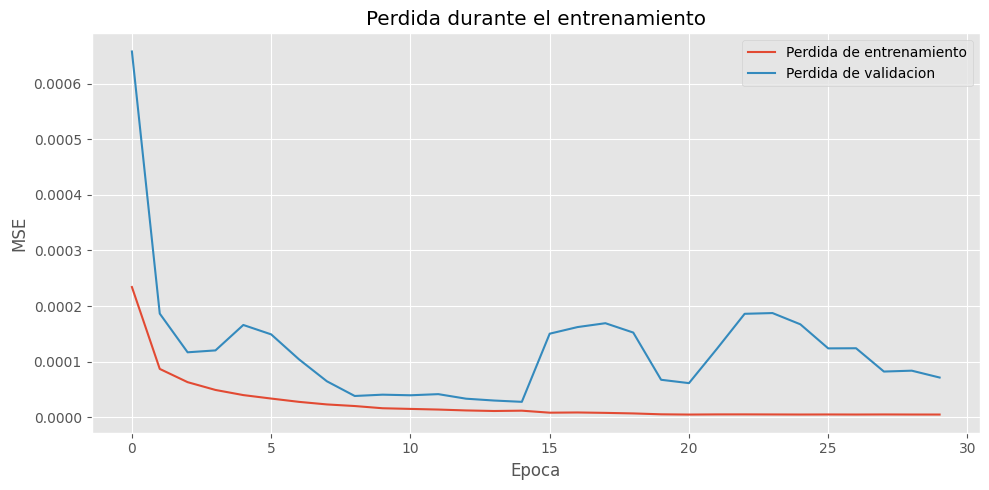

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(historial.history['loss'], label='Perdida de entrenamiento')
plt.plot(historial.history['val_loss'], label='Perdida de validacion')
plt.title('Perdida durante el entrenamiento')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


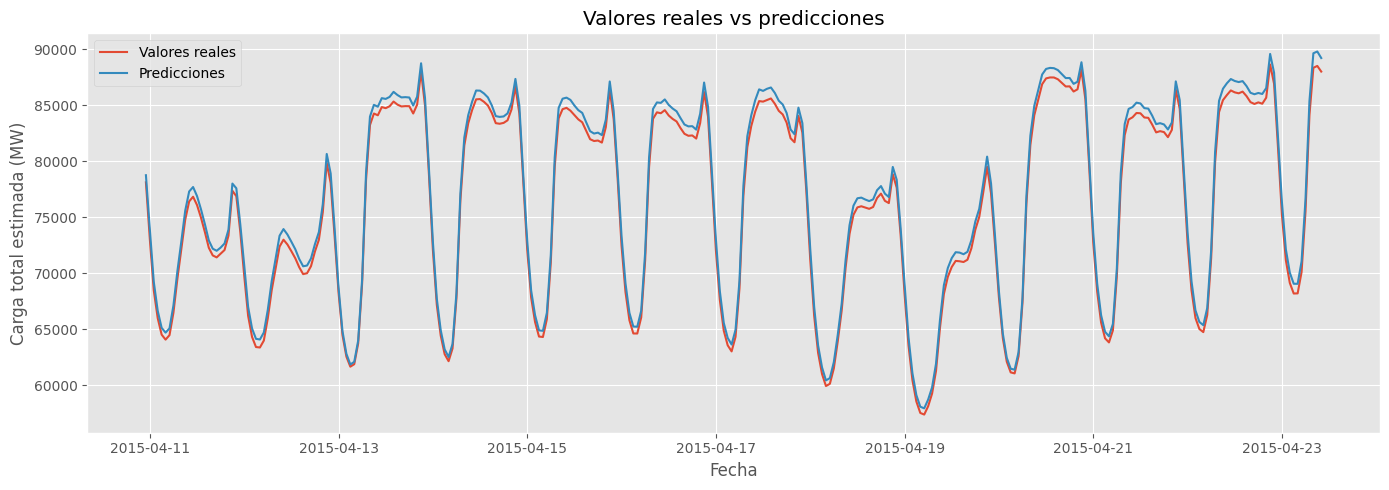

In [19]:
fechas_prueba = datos_modelo['Datetime'].iloc[indice_corte:].reset_index(drop=True)
cantidad_muestras = min(300, len(valores_reales))

plt.figure(figsize=(14, 5))
plt.plot(fechas_prueba.iloc[:cantidad_muestras], valores_reales[:cantidad_muestras], label='Valores reales')
plt.plot(fechas_prueba.iloc[:cantidad_muestras], predicciones[:cantidad_muestras], label='Predicciones')
plt.title('Valores reales vs predicciones')
plt.xlabel('Fecha')
plt.ylabel('Carga total estimada (MW)')
plt.legend()
plt.tight_layout()
plt.show()


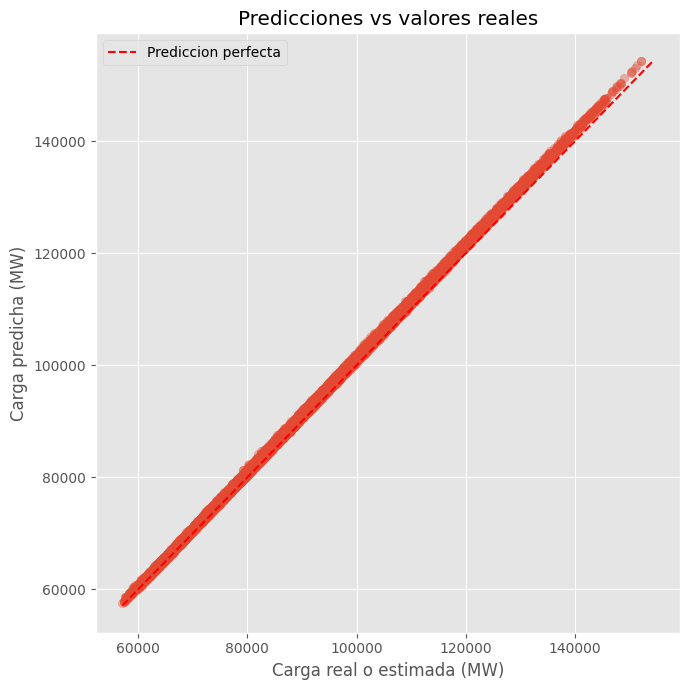

In [20]:
limite_minimo = min(valores_reales.min(), predicciones.min())
limite_maximo = max(valores_reales.max(), predicciones.max())

plt.figure(figsize=(7, 7))
plt.scatter(valores_reales, predicciones, alpha=0.35)
plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    color='red',
    linestyle='--',
    label='Prediccion perfecta'
)
plt.title('Predicciones vs valores reales')
plt.xlabel('Carga real o estimada (MW)')
plt.ylabel('Carga predicha (MW)')
plt.legend()
plt.tight_layout()
plt.show()


## 15. Prediccion individual

Finalmente se toma un registro del conjunto de prueba para revisar sus variables de entrada, la carga real o estimada, la carga predicha y el error absoluto.


In [21]:
indice_ejemplo = 0

registro_entrada = X_test.iloc[[indice_ejemplo]].copy()
registro_entrada_scaled = scaler_X.transform(registro_entrada)

prediccion_individual_scaled = modelo.predict(registro_entrada_scaled)
carga_predicha = scaler_y.inverse_transform(prediccion_individual_scaled)[0, 0]
carga_real = y_test.iloc[indice_ejemplo, 0]
error_absoluto = abs(carga_real - carga_predicha)

print('Variables de entrada del registro seleccionado:')
display(registro_entrada)

resultado_individual = pd.DataFrame({
    'Descripcion': ['Carga real o estimada', 'Carga predicha', 'Error absoluto'],
    'Valor en MW': [carga_real, carga_predicha, error_absoluto]
})

display(resultado_individual)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Variables de entrada del registro seleccionado:


,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,hora,dia_semana,mes,anio,consumo_hace_1_hora,consumo_hace_24_horas,consumo_hace_7_dias,promedio_24_horas
116155,12592.0,10520.0,1690.0,2610.0,9151.0,1348.0,1196.0,6872.0,0.0,27327.0,4817.0,23,4,4,2015,82632.0,83988.0,75804.0,81406.75


,Descripcion,Valor en MW
0,Carga real o estimada,78123.000000
1,Carga predicha,78759.507812
2,Error absoluto,636.507812


## 16. Conclusion

La red neuronal aprendio a relacionar la carga total estimada del sistema PJM con los consumos de varias zonas, variables de calendario y valores historicos de demanda.

El modelo aprende patrones generales del sistema PJM usando el consumo de varias zonas. Esto permite estimar la carga total del sistema con base en el comportamiento regional, el tiempo y el consumo historico.

Las variables regionales ayudan porque representan el aporte de diferentes zonas del sistema electrico. Las variables temporales ayudan a reconocer ciclos por hora, dia de la semana, mes y anio.

Los consumos pasados son importantes porque la demanda electrica suele tener continuidad. El valor de una hora se relaciona con horas cercanas y tambien puede repetirse en horarios similares de dias anteriores.

Para mejorar el proyecto se podrian agregar variables externas como clima, temperatura, humedad, dias festivos o informacion economica. Estos factores pueden influir en el consumo electrico y permitir predicciones mas precisas.
